# Feature marque — extraction + classification premium (3 paliers)

La baseline (notebook 02) **sous-estime le haut de gamme** car la marque est ignorée.
Ici on extrait la **marque** depuis `carmodel` et on la résume en un **palier premium** (généraliste / premium / luxe), puis on mesure le gain sur la régression.

**Pièges gérés :**
- Marques multi-mots (`ALFA ROMEO`, `LAND ROVER`, `ASTON MARTIN`) — extraction par correspondance avec une liste connue, pas « premier mot ».
- Classification premium en **3 paliers** (table `ml/references/premium_brand.csv`), encodée en niveau ordinal 0/1/2.

> Choix assumé : on privilégie une feature **interprétable** (le palier, posé à la main) plutôt qu'un encodage « boîte grise » type prix-moyen-par-marque. Atout pour BC04 (explicabilité).

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, "../../src")   # accès au code partagé ml/src/

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from features import load_premium_table, add_brand_features

df = pd.read_csv("../../data/french-second-hand-cars/processed/cars_clean.csv")
ref = load_premium_table("../../references/premium_brand.csv")
print("données:", df.shape, "| marques référencées:", len(ref))

données: (2340, 11) | marques référencées: 44


## 🟦 1. PRÉPROCESSING — extraction marque + palier premium

In [2]:
df = add_brand_features(df, ref)   # ajoute marque, palier, niveau
print("marques non reconnues :", df["marque"].isna().sum())
print(df["palier"].value_counts().to_dict())
df[["carmodel", "marque", "palier", "niveau"]].head(3)

marques non reconnues : 0
{'generaliste': 1451, 'premium': 775, 'luxe': 114}


,carmodel,marque,palier,niveau
0,\n RENAULT TWINGO 3\n,RENAULT,generaliste,0
1,\n BMW SERIE 4 F36 GRAN COUPE\n,BMW,premium,1
2,\n BMW SERIE 2 F45 ACTIVE TOURER\n,BMW,premium,1


## 🟦 2. PRÉPROCESSING — features + split train/test

Socle : les 6 features numériques de la baseline + le `niveau` premium (0/1/2).
Même `random_state=42` → comparaison équitable avec la baseline.

In [3]:
base = ["annee", "kilometrage", "puissance_din", "puissance_fisc",
        "nombredeportes", "nombredeplaces"]
data = df[base + ["price", "niveau"]].dropna(subset=base + ["price"])
print(f"lignes utilisables : {len(data)}")

train, test = train_test_split(data, test_size=0.2, random_state=42)
y_train, y_test = train["price"], test["price"]
print("train:", len(train), "| test:", len(test))

lignes utilisables : 2229
train: 1783 | test: 446


## 🟩 3. ENTRAÎNEMENT + 🟥 ÉVALUATION — baseline vs + palier premium

- **Baseline** : 6 features numériques.
- **+ palier** : baseline + niveau premium (0/1/2).

In [4]:
def evaluer(feats, nom):
    model = LinearRegression().fit(train[feats], y_train)
    pred = model.predict(test[feats])
    return {
        "modèle": nom,
        "MAE (€)": round(mean_absolute_error(y_test, pred)),
        "RMSE (€)": round(np.sqrt(mean_squared_error(y_test, pred))),
        "R²": round(r2_score(y_test, pred), 3),
    }

resultats = pd.DataFrame([
    evaluer(base, "baseline (6 num)"),
    evaluer(base + ["niveau"], "+ palier premium"),
])
resultats

,modèle,MAE (€),RMSE (€),R²
0,baseline (6 num),7711,14815,0.717
1,+ palier premium,7556,14279,0.737


## 🟥 4. Effet du palier (coefficient appris)

Le palier ajoute **un seul coefficient** : combien d'euros gagne le prix estimé quand on monte d'un cran (généraliste → premium → luxe).

In [5]:
model = LinearRegression().fit(train[base + ["niveau"]], y_train)
coefs = pd.Series(model.coef_, index=base + ["niveau"])
print("coefficient du palier premium :", round(coefs["niveau"]), "€ par cran")

coefficient du palier premium : 10806 € par cran


## 🟥 5. Réel vs prédit (baseline vs + palier)

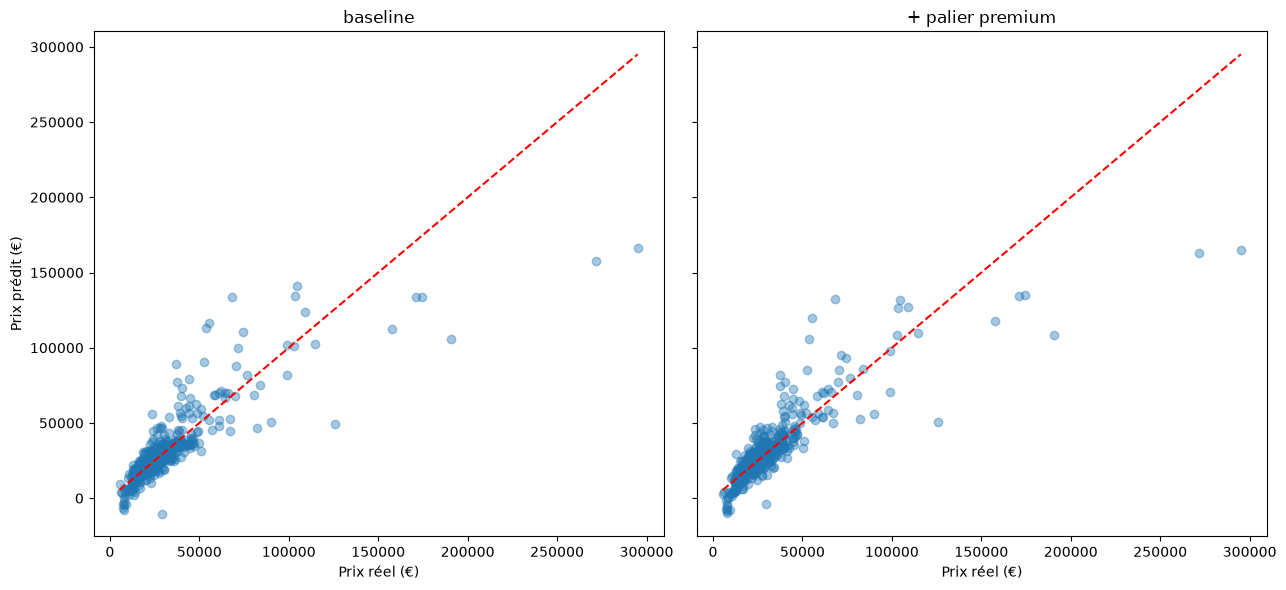

In [6]:
import matplotlib.pyplot as plt

m_base = LinearRegression().fit(train[base], y_train)
m_pal  = LinearRegression().fit(train[base + ["niveau"]], y_train)
p_base = m_base.predict(test[base])
p_pal  = m_pal.predict(test[base + ["niveau"]])

fig, ax = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True)
lims = [y_test.min(), y_test.max()]
for a, pred, titre in [(ax[0], p_base, "baseline"), (ax[1], p_pal, "+ palier premium")]:
    a.scatter(y_test, pred, alpha=0.4)
    a.plot(lims, lims, "r--")
    a.set_xlabel("Prix réel (€)"); a.set_title(titre)
ax[0].set_ylabel("Prix prédit (€)")
plt.tight_layout(); plt.show()

## Lecture

- Le **palier premium** apporte un gain modeste mais **interprétable** : le modèle sait qu'une premium/luxe vaut plus, via un seul coefficient lisible.
- Le linéaire reste limité (dépréciation non linéaire, 3 paliers = info grossière) → piste suivante = **modèle non linéaire** (RandomForest) qui exploitera mieux la marque.
- Toujours pas de **fourchette + incertitude** (exigence produit à venir).